# 06 · Safety Stock & Reorder Points

Step 5 produced weekly store forecasts. This notebook turns forecast error into an inventory policy:

1. Measure forecast error (bias and spread) by cluster, LightGBM vs seasonal naive
2. Validate the safety-stock method out of sample: calibrate on earlier backtest windows, test on the last one
3. Set safety stock, reorder points, and order-up-to levels for all stores
4. Quantify how much inventory the better forecast frees up
5. Export the store-level policy for the Tableau dashboard (Step 9)

**Note:** Rossmann reports sales in euros, not units, so inventory is expressed in sales value (€). Cost-based figures use an assumed cost-of-goods ratio, set below.

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

DATA    = "../data/processed/backtest_predictions.csv"
OUT     = "../data/processed/inventory_policy.csv"
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Policy assumptions (change here, everything below updates)
REVIEW_WEEKS   = 1      # stores place orders once a week
LEAD_WEEKS     = 1      # supplier lead time
TARGET_SL      = 0.95   # cycle service level: chance a week has no stockout
SERVICE_LEVELS = [0.90, 0.95, 0.98, 0.99]
COGS_RATIO     = 0.60   # inventory valued at cost = sales value x this (assumption)
HOLDING_RATE   = 0.20   # annual holding cost as a share of inventory at cost (assumption)

CLUSTER_NAMES = {1: "Weekday/promo-sensitive", 2: "Summer/tourist", 3: "Christmas-driven",
                 4: "Sunday-trading", 5: "Balanced week"}
MODELS = {"LGBM": "LightGBM", "Naive": "Seasonal naive"}

## 2. Load backtest predictions

In [2]:
bt = pd.read_csv(DATA, parse_dates=["WeekStart"])
n0 = len(bt)
bt = bt[(bt["WeeklySales"] > 0) & (bt["Pred_LGBM"] > 0) & (bt["Pred_Naive"] > 0)].copy()
print(f"{len(bt):,} of {n0:,} store-weeks kept (dropped closed weeks or missing predictions)")

cl_num = pd.to_numeric(bt["Cluster"], errors="coerce")
bt["ClusterName"] = cl_num.map(CLUSTER_NAMES) if cl_num.notna().all() else bt["Cluster"].astype(str)

bt.groupby("Window").agg(start=("WeekStart", "min"), end=("WeekStart", "max"),
                         weeks=("WeekStart", "nunique"), stores=("Store", "nunique"))

49,819 of 50,600 store-weeks kept (dropped closed weeks or missing predictions)


,start,end,weeks,stores
Window,,,,
W1 Spring 2014,2014-05-05,2014-07-21,12,1115
W2 Holiday 2014,2014-10-06,2014-12-22,12,935
W3 Early 2015,2015-02-02,2015-04-20,12,1115
W4 Summer 2015,2015-05-04,2015-07-20,12,1115


## 3. Forecast error by cluster

Relative error = (actual − forecast) / forecast. **Bias** is the average error (positive = the forecast runs low). **Spread** (standard deviation) is what safety stock has to cover.

In [3]:
for m in MODELS:
    bt[f"Err_{m}"] = (bt["WeeklySales"] - bt[f"Pred_{m}"]) / bt[f"Pred_{m}"]

def err_table(df):
    rows = {}
    for name, g in list(df.groupby("ClusterName")) + [("All stores", df)]:
        rows[name] = {"store_weeks": len(g),
                      "LGBM bias %": 100 * g["Err_LGBM"].mean(),  "LGBM spread %": 100 * g["Err_LGBM"].std(),
                      "Naive bias %": 100 * g["Err_Naive"].mean(), "Naive spread %": 100 * g["Err_Naive"].std()}
    return pd.DataFrame(rows).T

err_table(bt).round(1)

,store_weeks,LGBM bias %,LGBM spread %,Naive bias %,Naive spread %
Balanced week,21719.0,2.8,8.5,5.6,18.0
Christmas-driven,7746.0,2.5,10.5,4.1,24.3
Summer/tourist,384.0,3.6,11.7,3.8,13.8
Sunday-trading,788.0,3.4,8.5,8.0,13.8
Weekday/promo-sensitive,19182.0,2.1,7.9,3.8,18.5
All stores,49819.0,2.5,8.7,4.7,19.2


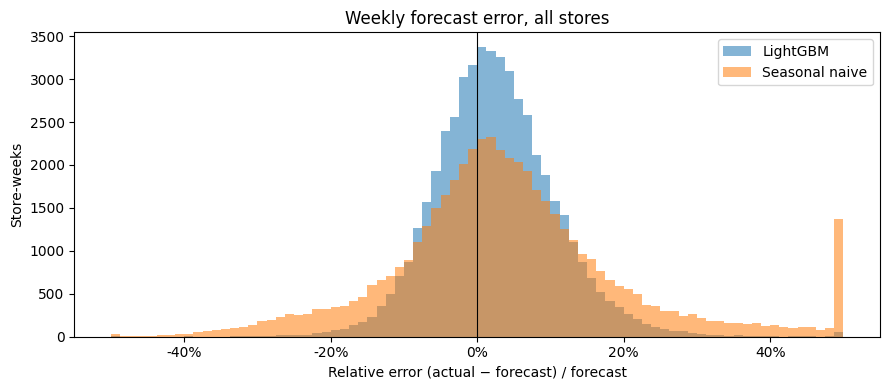

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(-0.5, 0.5, 81)
for m, label in MODELS.items():
    ax.hist(bt[f"Err_{m}"].clip(-0.5, 0.5), bins=bins, alpha=0.55, label=label)
ax.axvline(0, color="black", lw=0.8)
ax.set(title="Weekly forecast error, all stores", xlabel="Relative error (actual − forecast) / forecast",
       ylabel="Store-weeks")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/inventory_error_distribution.png", dpi=150)
plt.show()

**Finding:** LightGBM cuts forecast error spread by more than half (8.7% vs 19.2%), with no extreme misses, while the seasonal naive has a heavy right tail from promo-calendar shifts (errors of +50% or more). Both models under-forecast slightly; LightGBM's +2.5% bias is expected from training on log sales and is corrected in the reorder points. Summer/tourist (11.7%) and Christmas-driven (10.5%) stores are the most volatile and will need the largest buffers.

## 4. Out-of-sample validation

Safety stock is only useful if it delivers the service level it promises. Error parameters are estimated on the earlier backtest windows and tested on the last window, one week ahead.

Two methods:
- **Normal:** buffer = bias + z × spread (assumes errors are roughly bell-shaped)
- **Empirical:** buffer = the actual error quantile observed in calibration (no shape assumption)

A good method hits close to the target coverage with the smallest buffer.

In [5]:
windows = sorted(bt["Window"].unique())
assert len(windows) >= 2, "Need at least two backtest windows to validate"
cal, test = bt[bt["Window"] != windows[-1]], bt[bt["Window"] == windows[-1]]
print(f"Calibrate on windows {windows[:-1]} ({len(cal):,} store-weeks), test on window {windows[-1]} ({len(test):,})")

def buffer_factor(df, m, sl, method):
    """Per-cluster multiplier k: protected level = forecast x (1 + k)."""
    g = df.groupby("ClusterName")[f"Err_{m}"]
    if method == "normal":
        return g.mean() + norm.ppf(sl) * g.std()
    return g.quantile(sl)

rows = []
for m, label in MODELS.items():
    for method in ["normal", "empirical"]:
        for sl in SERVICE_LEVELS:
            k = test["ClusterName"].map(buffer_factor(cal, m, sl, method))
            level = test[f"Pred_{m}"] * (1 + k)
            rows.append({"model": label, "method": method, "target": f"{sl:.0%}",
                         "achieved": (test["WeeklySales"] <= level).mean(),
                         "buffer % of forecast": (level - test[f"Pred_{m}"]).sum() / test[f"Pred_{m}"].sum()})
val = pd.DataFrame(rows)
val.pivot_table(index=["model", "method"], columns="target",
                values=["achieved", "buffer % of forecast"]).map(lambda x: f"{x:.1%}")

Calibrate on windows ['W1 Spring 2014', 'W2 Holiday 2014', 'W3 Early 2015'] (37,190 store-weeks), test on window W4 Summer 2015 (12,629)


achieved                      buffer % of forecast  \
target                        90%    95%    98%    99%                  90%   
model          method                                                         
LightGBM       empirical    94.7%  97.7%  99.2%  99.5%                13.4%   
               normal       95.5%  97.8%  99.1%  99.4%                14.2%   
Seasonal naive empirical    98.0%  99.5%  99.8%  99.8%                27.6%   
               normal       98.6%  99.4%  99.7%  99.8%                30.4%   

                                               
target                      95%    98%    99%  
model          method                          
LightGBM       empirical  17.0%  21.7%  25.2%  
               normal     17.4%  21.1%  23.5%  
Seasonal naive empirical  42.2%  57.6%  66.2%  
               normal     37.6%  45.8%  51.2%

**Finding:**Both methods deliver at or above target out of sample, but conservatively: at a 95% target, LightGBM achieves 97.8% on Summer 2015 because calibration includes the Christmas 2014 window, which is more volatile. The normal and empirical methods perform almost identically for LightGBM, so the simpler normal method is used. At the same achieved service level (~98%), LightGBM needs a 17.4% buffer versus 27.6% for the seasonal naive, 37% less safety stock.

Set the method for the rest of the notebook based on the table above:

In [6]:
METHOD = "normal"   # switch to "empirical" if the normal method misses its targets

## 5. Store-level inventory policy

Error parameters are now re-estimated on all windows. Each store's weekly forecast is its average LightGBM forecast in the latest window.

- **Safety stock** = k × weekly forecast × √(protection weeks), where k excludes bias
- **Reorder point** (continuous review) = expected demand over lead time + safety stock over lead time
- **Order-up-to level** (weekly review, the periodic-review version of a reorder point) = expected demand over review + lead time + safety stock over that period

The √weeks scaling assumes weekly errors are independent; see limitations.

In [8]:
latest = bt[bt["Window"] == windows[-1]]

def policy(m, sl):
    k = buffer_factor(bt, m, sl, METHOD)
    bias = bt.groupby("ClusterName")[f"Err_{m}"].mean()
    p = latest.groupby(["Store", "ClusterName"])[f"Pred_{m}"].mean().rename("WeeklyForecast").reset_index()
    kc, bc = p["ClusterName"].map(k), p["ClusterName"].map(bias)
    ss_per_week = (kc - bc).clip(lower=0) * p["WeeklyForecast"]
    H = REVIEW_WEEKS + LEAD_WEEKS
    p["SafetyStock"]  = ss_per_week * np.sqrt(H)
    p["ReorderPoint"] = p["WeeklyForecast"] * (1 + bc) * LEAD_WEEKS + ss_per_week * np.sqrt(LEAD_WEEKS)
    p["OrderUpTo"]    = p["WeeklyForecast"] * (1 + bc) * H + p["SafetyStock"]
    p["SS_pct_of_week"] = p["SafetyStock"] / p["WeeklyForecast"]
    return p

pol_lgbm, pol_naive = policy("LGBM", TARGET_SL), policy("Naive", TARGET_SL)
pol_lgbm.sort_values("SafetyStock", ascending=False).head(10).set_index("Store").style.format({"WeeklyForecast": "€{:,.0f}", "SafetyStock": "€{:,.0f}", "ReorderPoint": "€{:,.0f}", "OrderUpTo": "€{:,.0f}", "SS_pct_of_week": "{:.1%}"})

,ClusterName,WeeklyForecast,SafetyStock,ReorderPoint,OrderUpTo,SS_pct_of_week
Store,,,,,,
262,Sunday-trading,"€145,590","€28,747","€170,822","€329,736",19.7%
562,Sunday-trading,"€127,190","€25,114","€149,233","€288,063",19.7%
1114,Balanced week,"€121,011","€23,992","€141,406","€272,874",19.8%
817,Weekday/promo-sensitive,"€119,794","€22,114","€138,000","€266,840",18.5%
842,Balanced week,"€108,494","€21,510","€126,779","€244,649",19.8%
733,Sunday-trading,"€108,804","€21,484","€127,661","€246,423",19.7%
251,Balanced week,"€107,596","€21,332","€125,730","€242,625",19.8%
788,Balanced week,"€106,083","€21,032","€123,962","€239,212",19.8%
586,Christmas-driven,"€86,162","€20,958","€103,158","€197,634",24.3%


## 6. Inventory freed by the better forecast

In [9]:
ss_l, ss_n = pol_lgbm["SafetyStock"].sum(), pol_naive["SafetyStock"].sum()
freed_cost = (ss_n - ss_l) * COGS_RATIO
print(f"Target service level {TARGET_SL:.0%}, method: {METHOD}, {len(pol_lgbm):,} stores")
print(f"Safety stock, seasonal naive: €{ss_n/1e6:,.1f}M (sales value)")
print(f"Safety stock, LightGBM:       €{ss_l/1e6:,.1f}M (sales value)")
print(f"Reduction: {1 - ss_l/ss_n:.1%}")
print(f"Inventory freed at cost: €{freed_cost/1e6:,.1f}M -> about €{freed_cost*HOLDING_RATE/1e6:,.1f}M/year in holding cost")

by_cluster = pd.DataFrame({
    "stores": pol_lgbm.groupby("ClusterName").size(),
    "LightGBM SS % of week": pol_lgbm.groupby("ClusterName")["SafetyStock"].sum() / pol_lgbm.groupby("ClusterName")["WeeklyForecast"].sum(),
    "Naive SS % of week":    pol_naive.groupby("ClusterName")["SafetyStock"].sum() / pol_naive.groupby("ClusterName")["WeeklyForecast"].sum(),
})
by_cluster["reduction"] = 1 - by_cluster["LightGBM SS % of week"] / by_cluster["Naive SS % of week"]
by_cluster.style.format({"LightGBM SS % of week": "{:.1%}", "Naive SS % of week": "{:.1%}", "reduction": "{:.0%}"})

Target service level 95%, method: normal, 1,115 stores
Safety stock, seasonal naive: €19.7M (sales value)
Safety stock, LightGBM:       €9.0M (sales value)
Reduction: 54.1%
Inventory freed at cost: €6.4M -> about €1.3M/year in holding cost


,stores,LightGBM SS % of week,Naive SS % of week,reduction
ClusterName,,,,
Balanced week,503,19.8%,41.9%,53%
Christmas-driven,173,24.3%,56.5%,57%
Summer/tourist,8,27.3%,32.0%,15%
Sunday-trading,17,19.7%,32.1%,38%
Weekday/promo-sensitive,414,18.5%,43.1%,57%


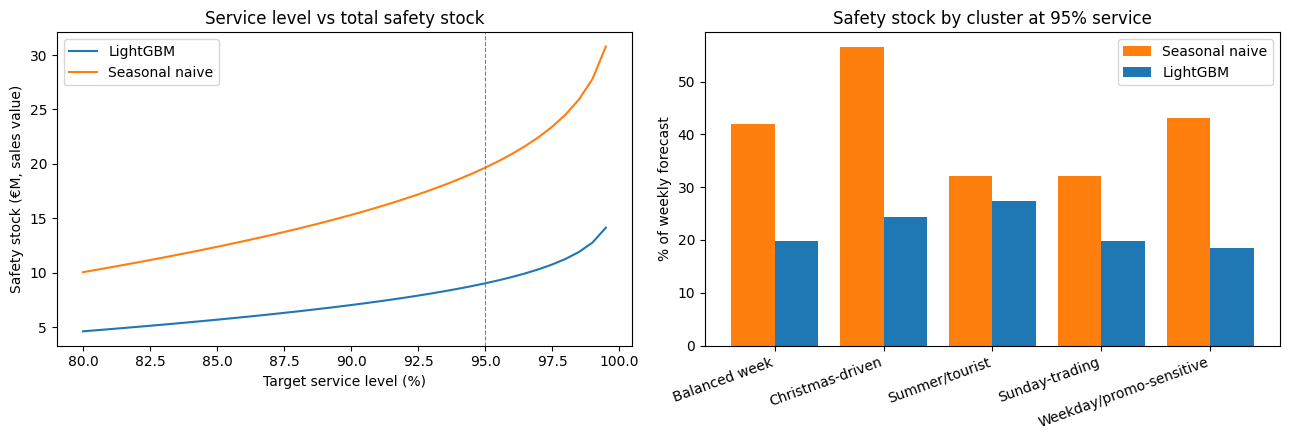

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sls = np.round(np.arange(0.80, 0.996, 0.005), 3)
for m, label in MODELS.items():
    axes[0].plot(sls * 100, [policy(m, s)["SafetyStock"].sum() / 1e6 for s in sls], label=label)
axes[0].axvline(TARGET_SL * 100, color="grey", ls="--", lw=0.8)
axes[0].set(title="Service level vs total safety stock", xlabel="Target service level (%)",
            ylabel="Safety stock (€M, sales value)")
axes[0].legend()

x = np.arange(len(by_cluster))
axes[1].bar(x - 0.2, by_cluster["Naive SS % of week"] * 100, 0.4, label="Seasonal naive", color="C1")
axes[1].bar(x + 0.2, by_cluster["LightGBM SS % of week"] * 100, 0.4, label="LightGBM", color="C0")
axes[1].set_xticks(x, by_cluster.index, rotation=20, ha="right")
axes[1].set(title=f"Safety stock by cluster at {TARGET_SL:.0%} service", ylabel="% of weekly forecast")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/inventory_safety_stock.png", dpi=150)
plt.show()

**Finding:** At a 95% service target, LightGBM cuts total safety stock from €19.7M to €9.0M in sales value (54%), freeing about €6.4M of inventory at cost (≈ €1.3M/year in holding cost, at an assumed 60% cost ratio and 20% holding rate). At the same *achieved* service level, the reduction is 37%. Gains are largest in promo-sensitive and Christmas-driven stores (57%), where the naive forecast breaks on promo-calendar shifts, and smallest in the 8 summer/tourist stores (15%), which need the largest buffer (27% of weekly sales) and are the clearest target for model improvement. With LightGBM, the chain could offer 99% service with less safety stock than the naive forecast needs for 90%.

## 7. Export for Tableau (Step 9)

In [12]:
export = pol_lgbm.merge(pol_naive[["Store", "SafetyStock"]].rename(columns={"SafetyStock": "SafetyStock_Naive"}), on="Store")
export["TargetServiceLevel"] = TARGET_SL
export["Method"] = METHOD
export.round(2).to_csv(OUT, index=False)
print(f"Saved {len(export):,} stores to {OUT}")

Saved 1,115 stores to ../data/processed/inventory_policy.csv


## Summary of findings

- **Forecast error:** LightGBM cuts the spread of weekly errors by more than half (8.7% vs 19.2%) with no extreme misses. Its slight under-forecast (+2.5%), expected from training on log sales, is corrected in the reorder points.
- **Validation:** out of sample (Summer 2015), a 95% target delivered 97.8% actual service. Buffers are slightly conservative because calibration includes Christmas 2014. The normal and empirical methods performed almost identically, so the simpler normal method is used.
- **Headline:** at the same achieved service level, LightGBM needs 37% less safety stock than the seasonal naive (54% at the same 95% target: €19.7M → €9.0M in sales value), freeing about €6.4M of inventory at cost, or ≈ €1.3M/year in holding cost.
- **Clusters:** gains are largest in promo-sensitive and Christmas-driven stores (57%) and smallest in the 8 summer/tourist stores (15%), which need the largest buffer (27% of weekly sales).
- **Recommendation:** use a 95% service target. LightGBM could deliver 99% service with less safety stock than the naive needs for 90%, but moving from 95% to 99% adds about 40% more stock.

**Assumptions and limitations**
- Inventory is in sales value (€); Rossmann has no unit or cost data, so cost figures depend on the assumed cost-of-goods ratio (60%) and holding rate (20%).
- Lead time and review period are assumed (1 week each), not observed.
- √weeks scaling assumes weekly errors are independent; if errors persist week to week, safety stock is understated.
- Error parameters are pooled by cluster, so individual stores with unusual volatility (such as stores 789 and 794) may need manual review.
- One set of buffers is used year-round. Separate holiday (Nov–Dec) and regular-season buffers would likely free more stock outside the holidays.